In [1]:
import scipy.signal as sig
import numpy as np
import matplotlib.pyplot as plt
import scipy.io as sio
from itertools import accumulate


In [2]:
sio.whosmat("ECG_TP4.mat")
mat_struct = sio.loadmat("ECG_TP4.mat")

ecg_one_lead = mat_struct["ecg_lead"]
ecg_one_lead = ecg_one_lead.flatten()[:10000]

ppg = np.genfromtxt('PPG.csv', delimiter=',', skip_header=1)  # Omitir la cabecera si existe

fs_audio, wav_data = sio.wavfile.read('la cucaracha.wav')


In [33]:
fs_ecg = 1000  # Hz
nyq_frec_ecg = fs_ecg / 2

fs_ppg = 400  # Hz
nyq_frec_ppg = fs_ppg / 2


fs_wav = fs_audio
nyq_frec_wav = fs_audio / 2



Observamos las distintas señales en el tiempo

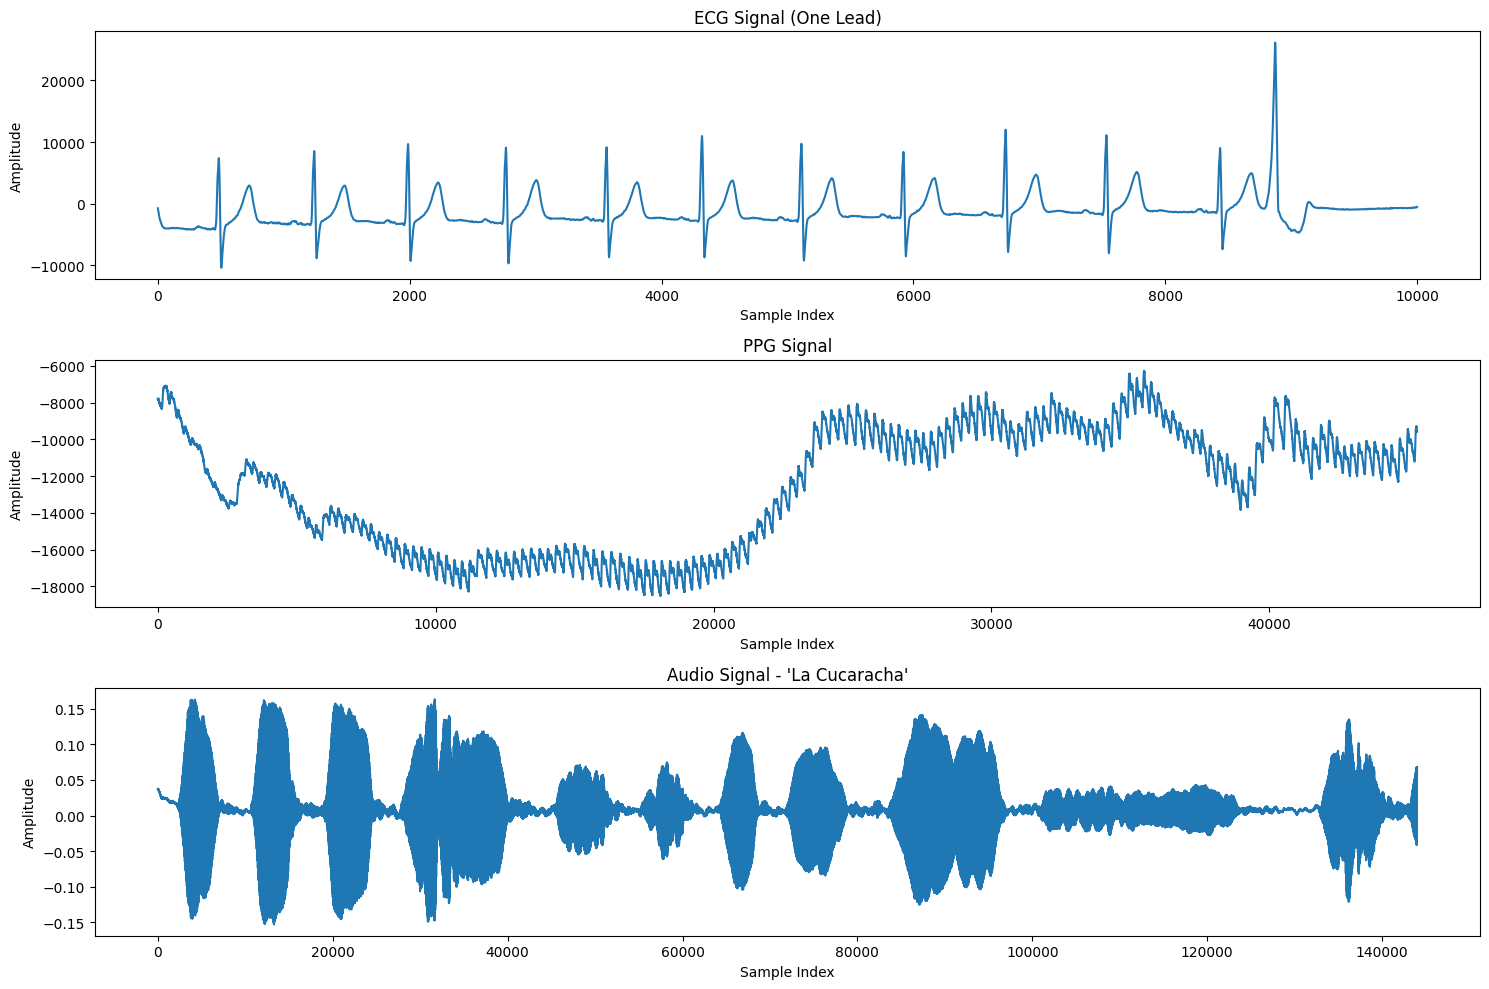

In [4]:
# Plotting
plt.figure(figsize=(15, 10))

# Plot ECG signal
plt.subplot(3, 1, 1)
plt.plot(ecg_one_lead)
plt.title("ECG Signal (One Lead)")
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")

# Plot PPG signal
plt.subplot(3, 1, 2)
plt.plot(ppg)
plt.title("PPG Signal")
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")

# Plot audio signal
plt.subplot(3, 1, 3)
plt.plot(wav_data)
plt.title("Audio Signal - 'La Cucaracha'")
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")

plt.tight_layout()
plt.show()

In [34]:
w = 5

N_ecg = len(ecg_one_lead)
N_ppg = len(ppg)
N_wav = len(wav_data)


df_p_ecg = (fs_ecg/N_ecg)
df_p_ppg = (fs_ppg/N_ppg)
df_p_wav = (fs_wav/N_wav)


df_w_ecg = df_p_ecg * w
df_w_ppg = df_p_ppg * w
df_w_wav = df_p_wav * w

In [35]:
ecg_one_lead_spectrum = (1/N_ecg)*np.fft.fft(ecg_one_lead)
ppg_spectrum = (1/N_ppg)*np.fft.fft(ppg)
wav_data_spectrum = (1/N_wav)*np.fft.fft(wav_data)

ecg_period_full = abs(ecg_one_lead_spectrum[:int(N_ecg/2)])**2
ppg_period_full = abs(ppg_spectrum[:int(N_ppg/2)])**2
wav_period_full = abs(wav_data_spectrum[:int(N_wav/2)])**2

ecg_period = ecg_period_full[:int(N_ecg/2)]
ppg_period = ppg_period_full[:int(N_ppg/2)]
wav_period = wav_period_full[:int(N_wav/2)]

f_period_ecg = np.linspace(0, (N_ecg - 1) * df_p_ecg, N_ecg)
f_period_ppg = np.linspace(0, (N_ppg - 1) * df_p_ppg, N_ppg)
f_period_wav = np.linspace(0, (N_wav - 1) * df_p_wav, N_wav)



In [36]:
f_welch_ecg, ecg_welch = sig.welch(ecg_one_lead, fs=fs_ecg, nperseg=(N_ecg/w))
f_welch_ppg, ppg_welch = sig.welch(ppg, fs=fs_ppg, nperseg=(N_ppg/w))
f_welch_wav, wav_welch = sig.welch(wav_data, fs=fs_wav, nperseg=(N_wav/w))

f_period_ecg, ecg_period = sig.periodogram(ecg_one_lead, fs=fs_ecg)
f_period_ppg, ppg_period = sig.periodogram(ppg, fs=fs_ppg)
f_period_wav, wav_period = sig.periodogram(wav_data, fs=fs_wav)


In [37]:
#ECG
norm_p = ecg_period.sum()
Pxx_ecg_period_normalized = ecg_period / norm_p

norm_w = ecg_welch.sum()
Pxx_ecg_welch_normalized = ecg_welch / norm_w

#ppg
norm_p = ppg_period.sum()
Pxx_ppg_period_normalized = ppg_period / norm_p

norm_w = ppg_welch.sum()
Pxx_ppg_welch_normalized = ppg_welch / norm_w

#WAV
norm_p = wav_period.sum()
Pxx_wav_period_normalized = wav_period / norm_p

norm_w = wav_welch.sum()
Pxx_wav_welch_normalized = wav_welch / norm_w

In [38]:
Pxx_ecg_period_normalized_db = 10 * np.log(Pxx_ecg_period_normalized)
Pxx_ecg_welch_normalized_db = 10 * np.log(Pxx_ecg_welch_normalized)

Pxx_ppg_period_normalized_db = 10 * np.log(Pxx_ppg_period_normalized)
Pxx_ppg_welch_normalized_db = 10 * np.log(Pxx_ppg_welch_normalized)

Pxx_wav_period_normalized_db = 10 * np.log(Pxx_wav_period_normalized)
Pxx_wav_welch_normalized_db = 10 * np.log(Pxx_wav_welch_normalized)

Ahora vamos a observar las densidades espectrales de potencia estimadas con el método del periodograma y el metodo de welch

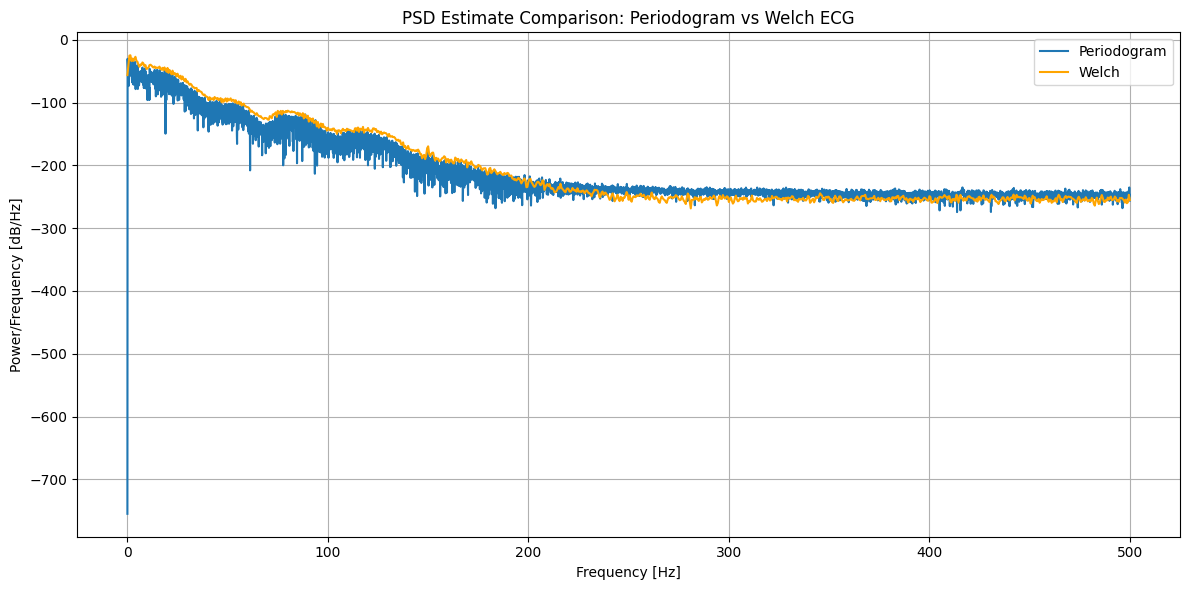

In [39]:
plt.figure(figsize=(12, 6))

plt.plot(f_period_ecg, Pxx_ecg_period_normalized_db, label="Periodogram")
plt.plot(f_welch_ecg,  Pxx_ecg_welch_normalized_db, label="Welch", color="orange")

plt.title("PSD Estimate Comparison: Periodogram vs Welch ECG")
plt.xlabel("Frequency [Hz]")
plt.ylabel("Power/Frequency [dB/Hz]")

plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

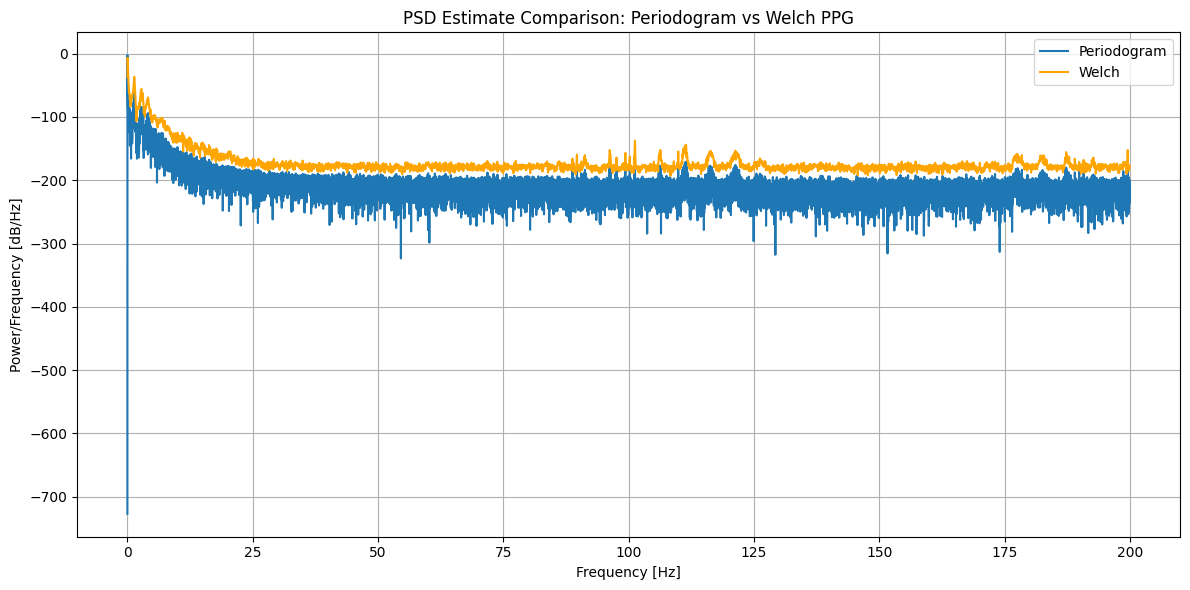

In [40]:
plt.figure(figsize=(12, 6))

plt.plot(f_period_ppg, Pxx_ppg_period_normalized_db, label="Periodogram")
plt.plot(f_welch_ppg,  Pxx_ppg_welch_normalized_db, label="Welch", color="orange")

plt.title("PSD Estimate Comparison: Periodogram vs Welch PPG")
plt.xlabel("Frequency [Hz]")
plt.ylabel("Power/Frequency [dB/Hz]")

plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

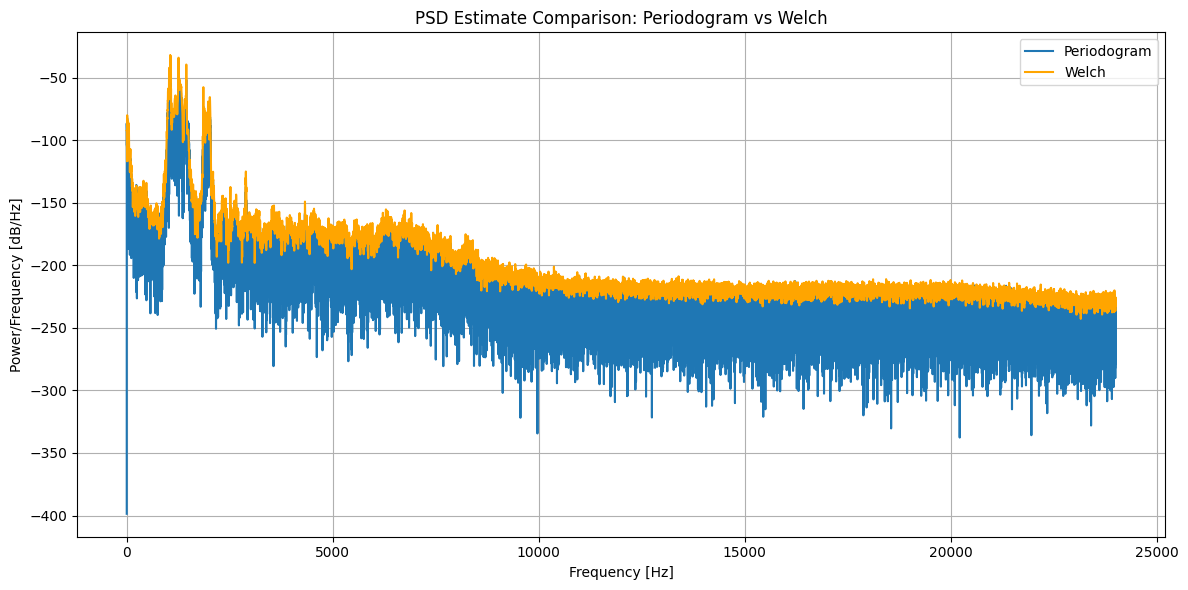

In [41]:
plt.figure(figsize=(12, 6))

plt.plot(f_period_wav, Pxx_wav_period_normalized_db, label="Periodogram")
plt.plot(f_welch_wav,  Pxx_wav_welch_normalized_db, label="Welch", color="orange")

plt.title("PSD Estimate Comparison: Periodogram vs Welch")
plt.xlabel("Frequency [Hz]")
plt.ylabel("Power/Frequency [dB/Hz]")

plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

Para estimar el ancho de banda, se pueden tomar distintos criterios. En este caso opte por elegir como criterio la freq a la cual se encuentre contenida el 99% de la potencia para todas las señales

In [47]:
p_bw_ecg = 0.99

p_cumulative = np.array(list(accumulate(Pxx_ecg_period_normalized)))
p_index_ecg = np.argmax(p_cumulative >= p_bw_ecg)

w_bw_ecg = 0.99

w_cumulative = np.array(list(accumulate(Pxx_ppg_welch_normalized)))
w_index_ecg = np.argmax(w_cumulative >= w_bw_ecg)

p_bw_ppg = 0.99

p_cumulative = np.array(list(accumulate(Pxx_ppg_period_normalized)))
p_index_ppg = np.argmax(p_cumulative >= p_bw_ppg)

w_bw_ppg = 0.99

w_cumulative = np.array(list(accumulate(Pxx_ppg_welch_normalized)))
w_index_ppg = np.argmax(w_cumulative >= w_bw_ppg)

p_bw_wav = 0.99

p_cumulative = np.array(list(accumulate(Pxx_wav_period_normalized)))
p_index_wav = np.argmax(p_cumulative >= p_bw_wav)

w_bw_wav = 0.99

w_cumulative = np.array(list(accumulate(Pxx_wav_welch_normalized)))
w_index_wav = np.argmax(w_cumulative >= w_bw_wav)

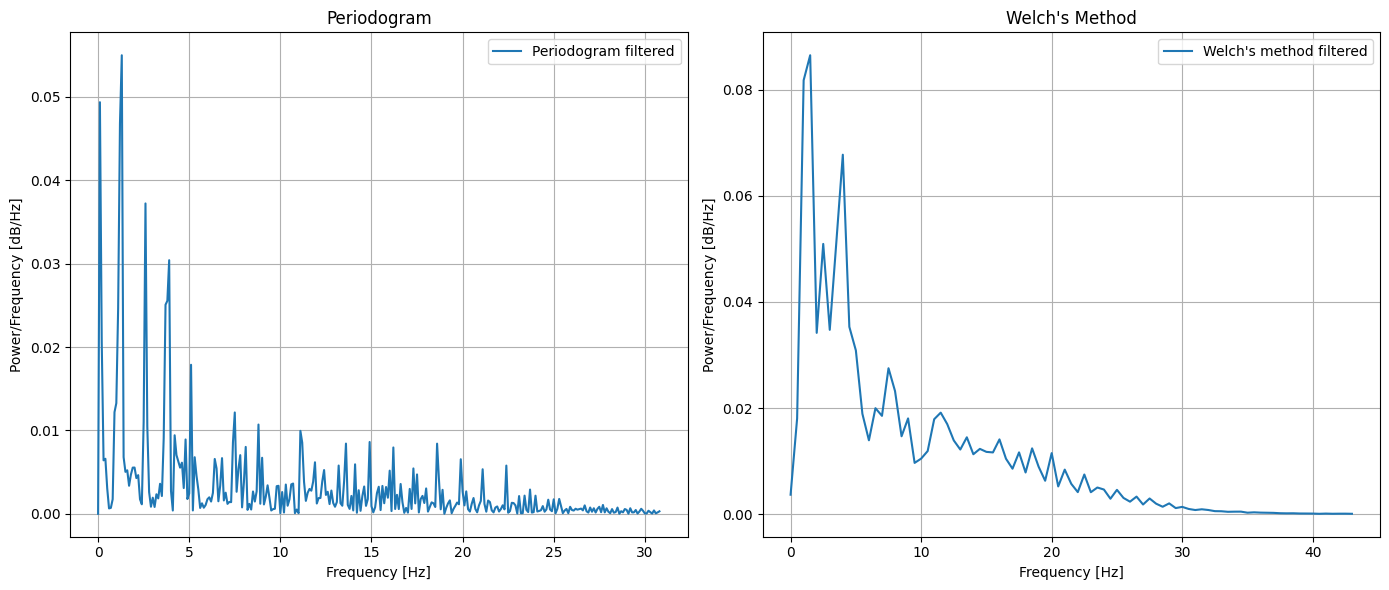

In [64]:
plt.figure(figsize=(14, 6))

# Periodogram subplot
plt.subplot(1, 2, 1)
plt.plot(
    f_period_ecg[:p_index_ecg], Pxx_ecg_period_normalized[:p_index_ecg], label="Periodogram filtered"
)
plt.xlabel("Frequency [Hz]")
plt.ylabel("Power/Frequency [dB/Hz]")
plt.title("Periodogram")
plt.grid(True)
plt.legend()

# Welch's method subplot
plt.subplot(1, 2, 2)
plt.plot(
    f_welch_ecg[:w_index_ecg], Pxx_ecg_welch_normalized[:w_index_ecg], label="Welch's method filtered"
)
plt.xlabel("Frequency [Hz]")
plt.ylabel("Power/Frequency [dB/Hz]")
plt.title("Welch's Method")
plt.grid(True)
plt.legend()

# Adjust layout and show the plots
plt.tight_layout()
plt.show()

In [63]:
w_index_ecg

np.int64(87)

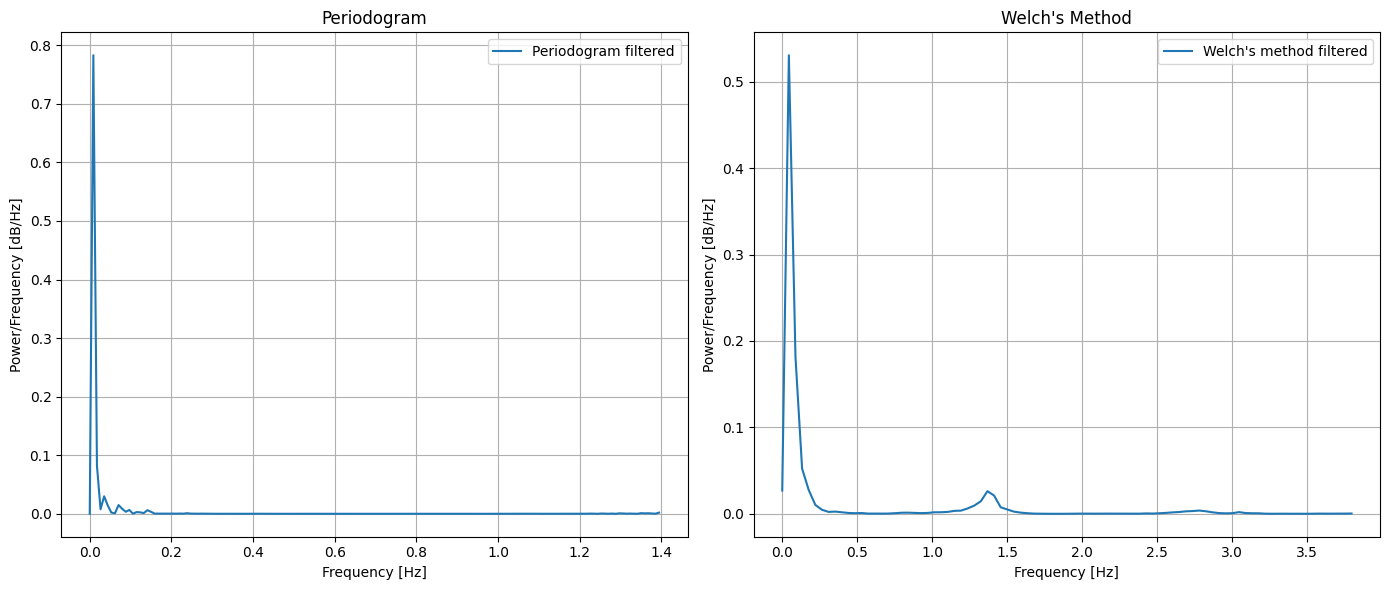

In [65]:
plt.figure(figsize=(14, 6))

# Periodogram subplot
plt.subplot(1, 2, 1)
plt.plot(
    f_period_ppg[:p_index_ppg], Pxx_ppg_period_normalized[:p_index_ppg], label="Periodogram filtered"
)
plt.xlabel("Frequency [Hz]")
plt.ylabel("Power/Frequency [dB/Hz]")
plt.title("Periodogram")
plt.grid(True)
plt.legend()

# Welch's method subplot
plt.subplot(1, 2, 2)
plt.plot(
    f_welch_ppg[:w_index_ppg], Pxx_ppg_welch_normalized[:w_index_ppg], label="Welch's method filtered"
)
plt.xlabel("Frequency [Hz]")
plt.ylabel("Power/Frequency [dB/Hz]")
plt.title("Welch's Method")
plt.grid(True)
plt.legend()

# Adjust layout and show the plots
plt.tight_layout()
plt.show()

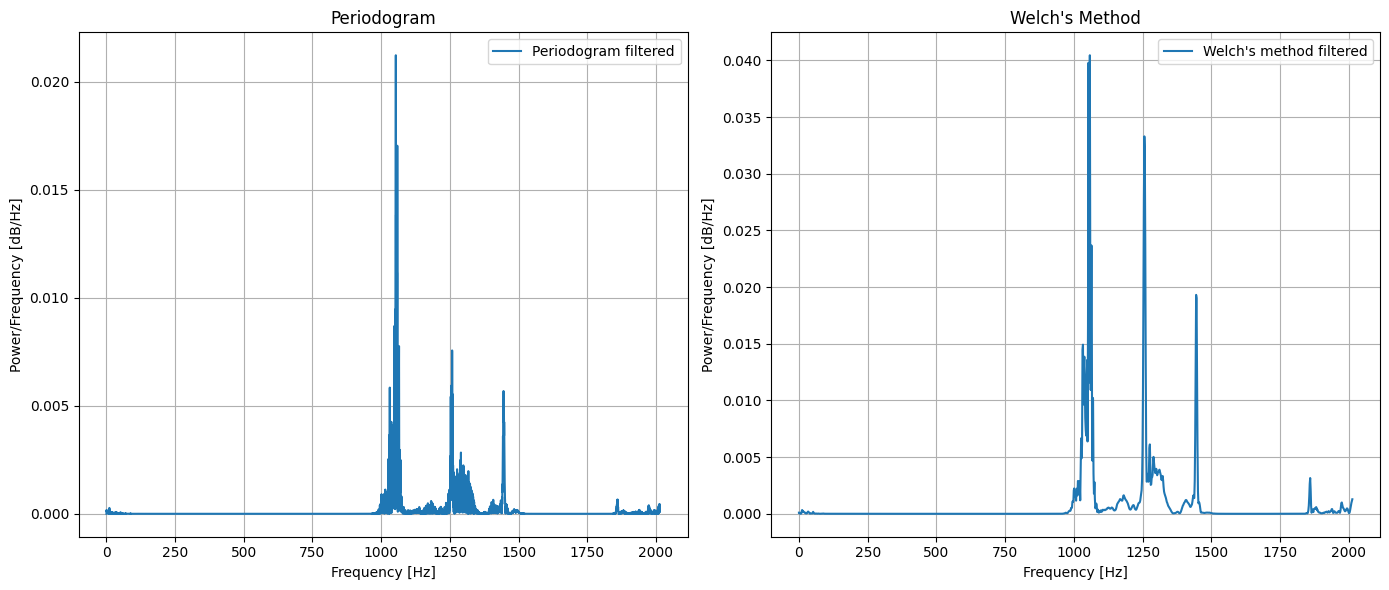

In [66]:
plt.figure(figsize=(14, 6))

# Periodogram subplot
plt.subplot(1, 2, 1)
plt.plot(
    f_period_wav[:p_index_wav], Pxx_wav_period_normalized[:p_index_wav], label="Periodogram filtered"
)
plt.xlabel("Frequency [Hz]")
plt.ylabel("Power/Frequency [dB/Hz]")
plt.title("Periodogram")
plt.grid(True)
plt.legend()

# Welch's method subplot
plt.subplot(1, 2, 2)
plt.plot(
    f_welch_wav[:w_index_wav], Pxx_wav_welch_normalized[:w_index_wav], label="Welch's method filtered"
)
plt.xlabel("Frequency [Hz]")
plt.ylabel("Power/Frequency [dB/Hz]")
plt.title("Welch's Method")
plt.grid(True)
plt.legend()

# Adjust layout and show the plots
plt.tight_layout()
plt.show()

In [58]:
import pandas as pd

Utilizando el criterio antes mencionado obtuve los siguientes anchos de banda para cada señal

In [72]:
columns = ['Signal', 'Estimated BW [Hz]']

data_period_ecg = ['ECG', 30]

data_period_ppg = ['PPG', 1.4]

data_period_wav = ['WAV', 2000]

rows = [data_period_ecg, data_period_ppg, data_period_wav]

resultados = pd.DataFrame(rows, columns=columns)
resultados

,Signal,Estimated BW [Hz]
0,ECG,30.0
1,PPG,1.4
2,WAV,2000.0
